In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Prvih 5 redova sirovih cena:
                  WTI       BRENT     NVDA
Date                                      
2013-01-01  93.190002  111.400002  0.31925
2013-01-08  94.139999  111.879997  0.30500
2013-01-15  95.559998  110.610001  0.30425
2013-01-22  96.440002  113.480003  0.31525
2013-01-29  96.169998  115.599998  0.30400

Dimenzije: (522, 3)

Prvih 5 redova log-cena:
             log_WTI  log_BRENT  log_NVDA
Date                                     
2013-01-01  4.534640   4.713127 -1.141781
2013-01-08  4.544783   4.717427 -1.187443
2013-01-15  4.559754   4.706011 -1.189906

Prvih 5 redova log-razlika (prinosa):
            Δlog_WTI  Δlog_BRENT  Δlog_NVDA
Date                                       
2013-01-08  0.010143    0.004300  -0.045663
2013-01-15  0.014971   -0.011416  -0.002462
2013-01-22  0.009167    0.025616   0.035516


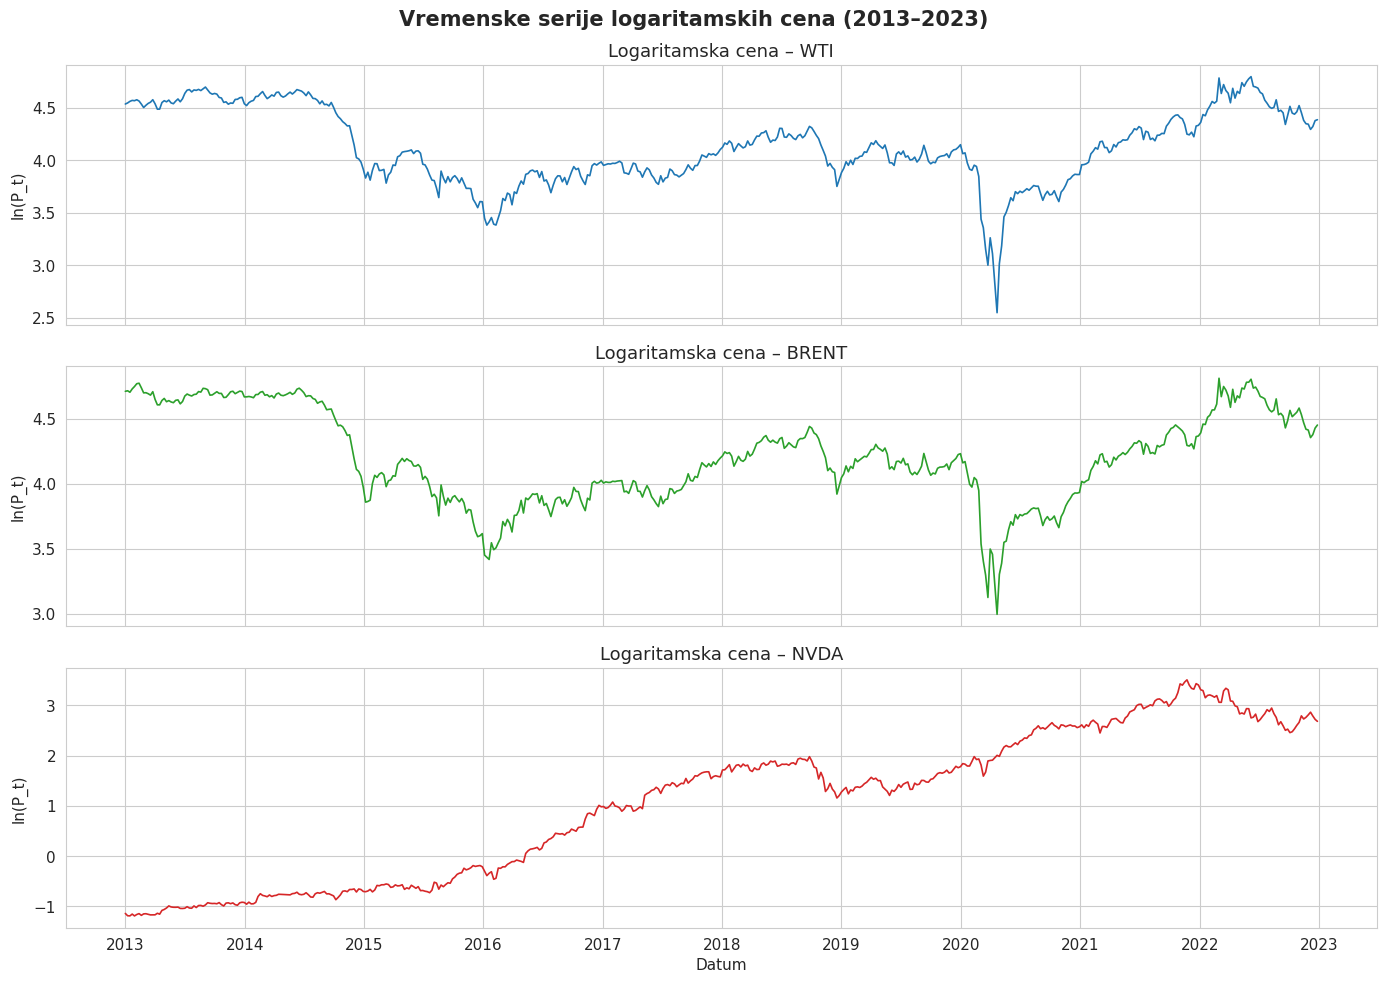

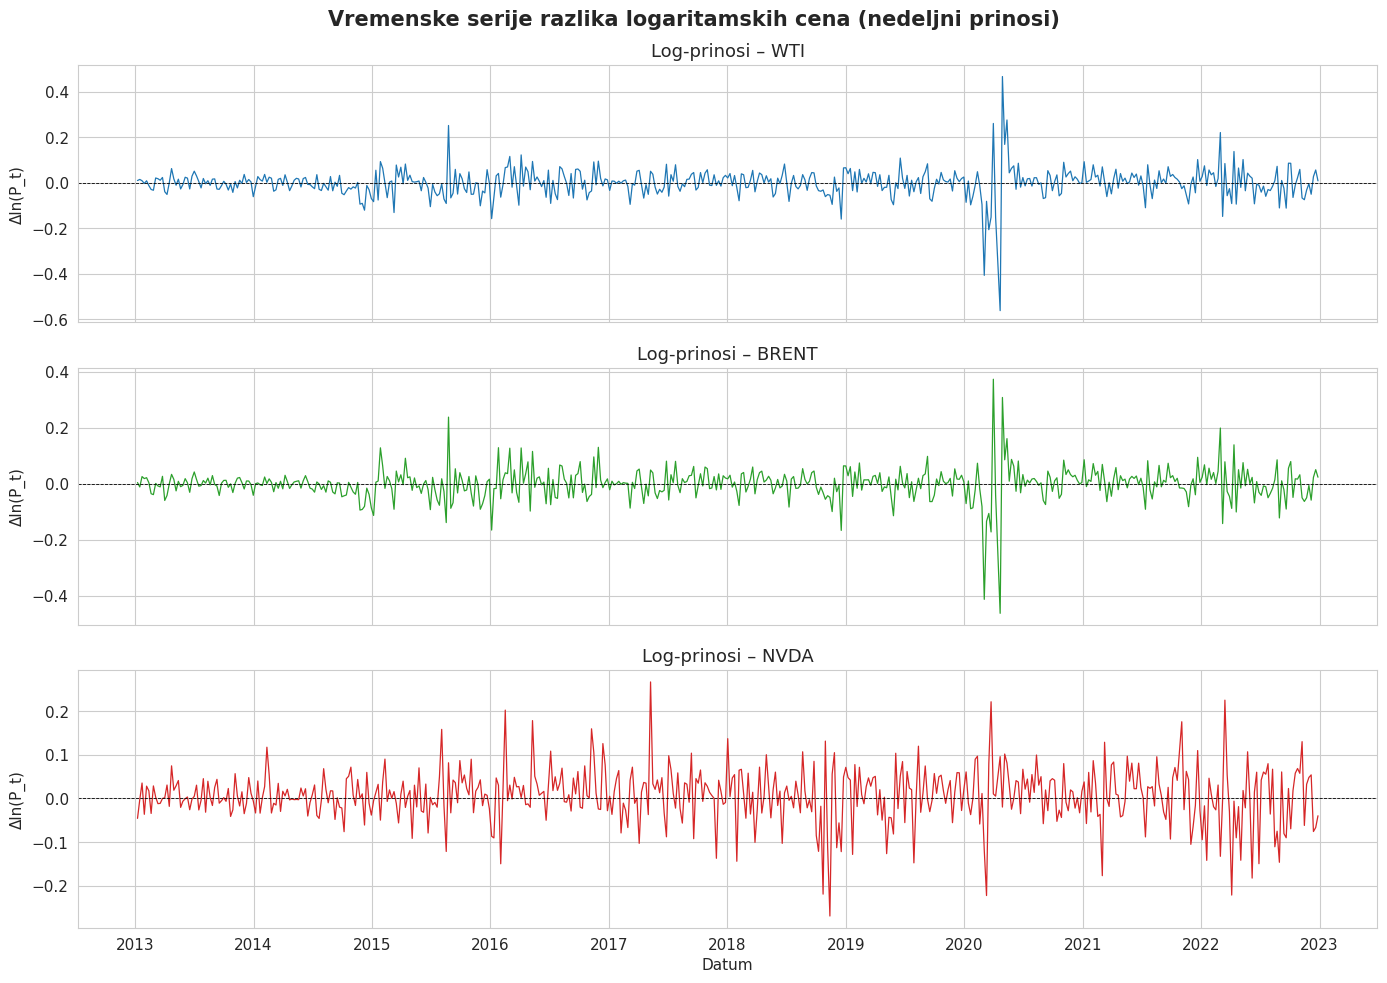

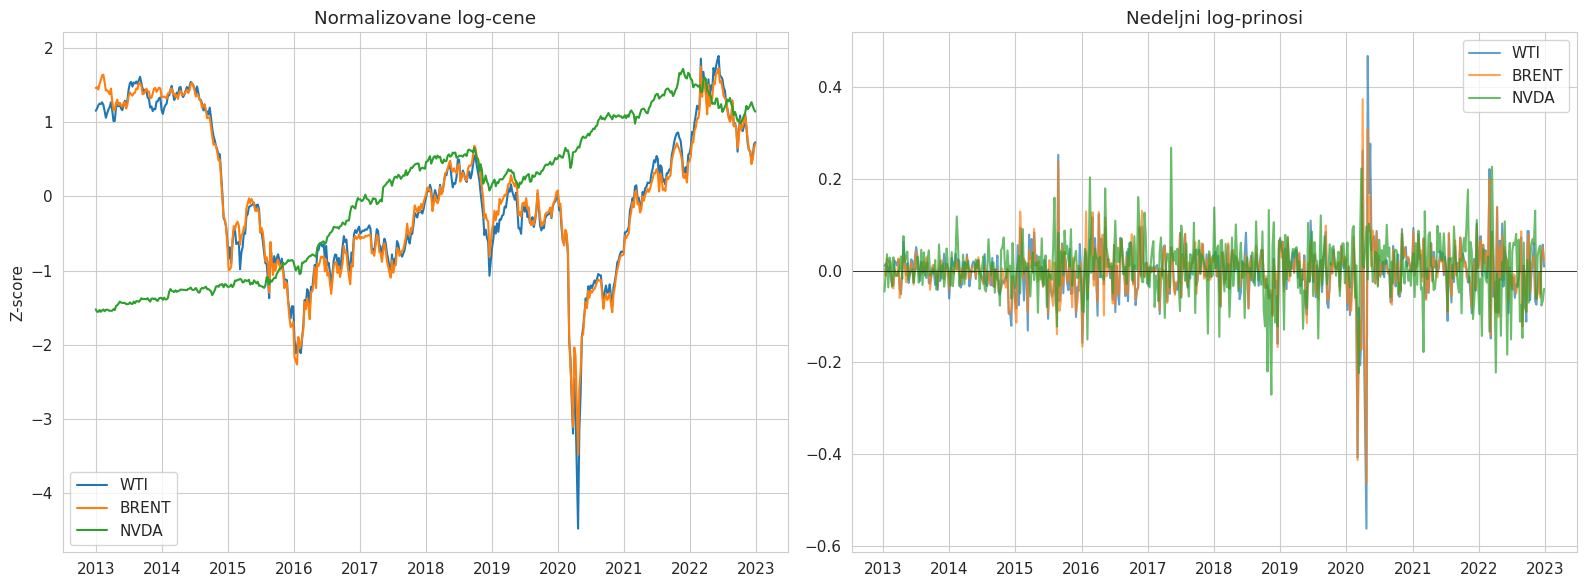

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

start_date = "2013-01-01"
end_date   = "2023-01-01"

tikeri = {
    "WTI":   "CL=F",
    "BRENT": "BZ=F",
    "NVDA":  "NVDA"
}

podaci = {}
for naziv, tiker in tikeri.items():
    df = yf.download(tiker, start=start_date, end=end_date, interval="1wk",
                     progress=False, auto_adjust=False)
    podaci[naziv] = df['Close'].copy()

cene = pd.concat(podaci, axis=1)
cene.columns = tikeri.keys()
cene = cene.dropna()

print("Prvih 5 redova sirovih cena:")
print(cene.head())
print("\nDimenzije:", cene.shape)
cene = cene[cene > 0].dropna()

log_cene = np.log(cene)
log_cene.columns = [f"log_{c}" for c in log_cene.columns]

log_razlike = log_cene.diff().dropna()
log_razlike.columns = [f"Δ{col}" for col in log_razlike.columns]

print("\nPrvih 5 redova log-cena:")
print(log_cene.head(3))
print("\nPrvih 5 redova log-razlika (prinosa):")
print(log_razlike.head(3))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

boje = {"log_WTI": "tab:blue", "log_BRENT": "tab:green", "log_NVDA": "tab:red"}

for ax, col in zip(axes, log_cene.columns):
    ax.plot(log_cene.index, log_cene[col], color=boje[col], linewidth=1.2)
    ax.set_title(f"Logaritamska cena – {col.replace('log_','')}", fontsize=13)
    ax.set_ylabel("ln(P_t)")

axes[-1].set_xlabel("Datum")
fig.suptitle("Vremenske serije logaritamskih cena (2013–2023)", fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig("log_cene.png", dpi=150)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, log_razlike.columns):
    ax.plot(log_razlike.index, log_razlike[col],
            color=boje[col.replace('Δ','')], linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f"Log-prinosi – {col.replace('Δlog_','').replace('log_','')}", fontsize=13)
    ax.set_ylabel("Δln(P_t)")

axes[-1].set_xlabel("Datum")
fig.suptitle("Vremenske serije razlika logaritamskih cena (nedeljni prinosi)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig("log_razlike.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

norm_log = (log_cene - log_cene.mean()) / log_cene.std()
for col in norm_log.columns:
    axes[0].plot(norm_log.index, norm_log[col], label=col.replace('log_',''))
axes[0].set_title("Normalizovane log-cene")
axes[0].set_ylabel("Z-score")
axes[0].legend()

for col in log_razlike.columns:
    axes[1].plot(log_razlike.index, log_razlike[col], alpha=0.7,
                 label=col.replace('Δlog_','').replace('log_',''))
axes[1].set_title("Nedeljni log-prinosi")
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf

def evaluate_white_noise(series, lags=20, alpha=0.05):
    print("=" * 60)
    print("        WEAK WHITE NOISE DIAGNOSTIC REPORT          ")
    print("=" * 60)

    lb_result = acorr_ljungbox(series, lags=[lags], return_df=True)
    lb_pvalue = lb_result['lb_pvalue'].iloc[0]
    bp_pvalue = lb_result['bp_pvalue'].iloc[0] if 'bp_pvalue' in lb_result else None

    print("\n1. AUTOCORRELATION TESTS (Linear Independence)")
    print(f"   • Ljung-Box Test (Lag {lags}): p-value = {lb_pvalue:.4f}")
    if bp_pvalue is not None:
        print(f"   • Box-Pierce Test (Lag {lags}): p-value = {bp_pvalue:.4f}")

    if lb_pvalue > alpha:
        print("   --> RESULT: PASS (No significant autocorrelation detected)")
    else:
        print("   --> RESULT: FAIL (Significant autocorrelation present)")

    adf_result = adfuller(series)
    adf_pvalue = adf_result[1]

    print("\n2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)")
    print(f"   • ADF Statistic: {adf_result[0]:.4f}")
    print(f"   • p-value: {adf_pvalue:.4f}")

    if adf_pvalue < alpha:
        print("   --> RESULT: PASS (Series is stationary around a constant mean)")
    else:
        print("   --> RESULT: FAIL (Unit root detected; mean or trend is shifting)")

    demeaned_series = series - series.mean()
    arch_result = het_arch(demeaned_series, maxlag=lags)
    arch_pvalue = arch_result[1]  # p-value of LM test

    print("\n3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)")
    print(f"   • ARCH LM p-value: {arch_pvalue:.4f}")

    if arch_pvalue > alpha:
        print("   --> RESULT: PASS (Constant variance / No volatility clustering)")
    else:
        print("   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)")

    print("\n" + "-" * 60)
    if lb_pvalue > alpha and adf_pvalue < alpha and arch_pvalue > alpha:
        print("FINAL VERDICT: The series BEHAVES LIKE WEAK WHITE NOISE.")
    elif lb_pvalue > alpha and adf_pvalue < alpha:
        print("FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).")
    else:
        print("FINAL VERDICT: The series DOES NOT behave like Weak White Noise.")
    print("-" * 60)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.tight_layout(pad=4.0)

    rolling_window = max(10, len(series) // 20)
    roll_mean = series.rolling(rolling_window).mean()
    roll_std = series.rolling(rolling_window).std()

    axes[0].plot(series.values, label="Data", color="gray", alpha=0.6)
    axes[0].plot(roll_mean.values, label=f"Rolling Mean (win={rolling_window})", color="red", linewidth=1.5)
    axes[0].plot(roll_std.values, label=f"Rolling Std Dev (win={rolling_window})", color="blue", linewidth=1.5)
    axes[0].set_title("Time Series & Rolling Moments")
    axes[0].legend()
    axes[0].grid(True, linestyle=":", alpha=0.6)

    plot_acf(series, lags=lags, ax=axes[1], alpha=alpha)
    axes[1].set_title(f"Autocorrelation Function (ACF) with {int((1-alpha)*100)}% Confidence Bounds")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    axes[2].plot(demeaned_series.values**2, color="purple", alpha=0.7)
    axes[2].set_title("Squared Deviations $(X_t - \\mu)^2$ (Variance Stability Check)")
    axes[2].grid(True, linestyle=":", alpha=0.6)

    plt.show()


 TESTIRANJE BELE BUKE ZA: Δlog_WTI
        WEAK WHITE NOISE DIAGNOSTIC REPORT          

1. AUTOCORRELATION TESTS (Linear Independence)
   • Ljung-Box Test (Lag 15): p-value = 0.1701
   --> RESULT: PASS (No significant autocorrelation detected)

2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)
   • ADF Statistic: -12.1047
   • p-value: 0.0000
   --> RESULT: PASS (Series is stationary around a constant mean)

3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)
   • ARCH LM p-value: 0.0000
   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)

------------------------------------------------------------
FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).
------------------------------------------------------------


/tmp/ipykernel_3525/1664317080.py:37: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_result = het_arch(demeaned_series, maxlag=lags)


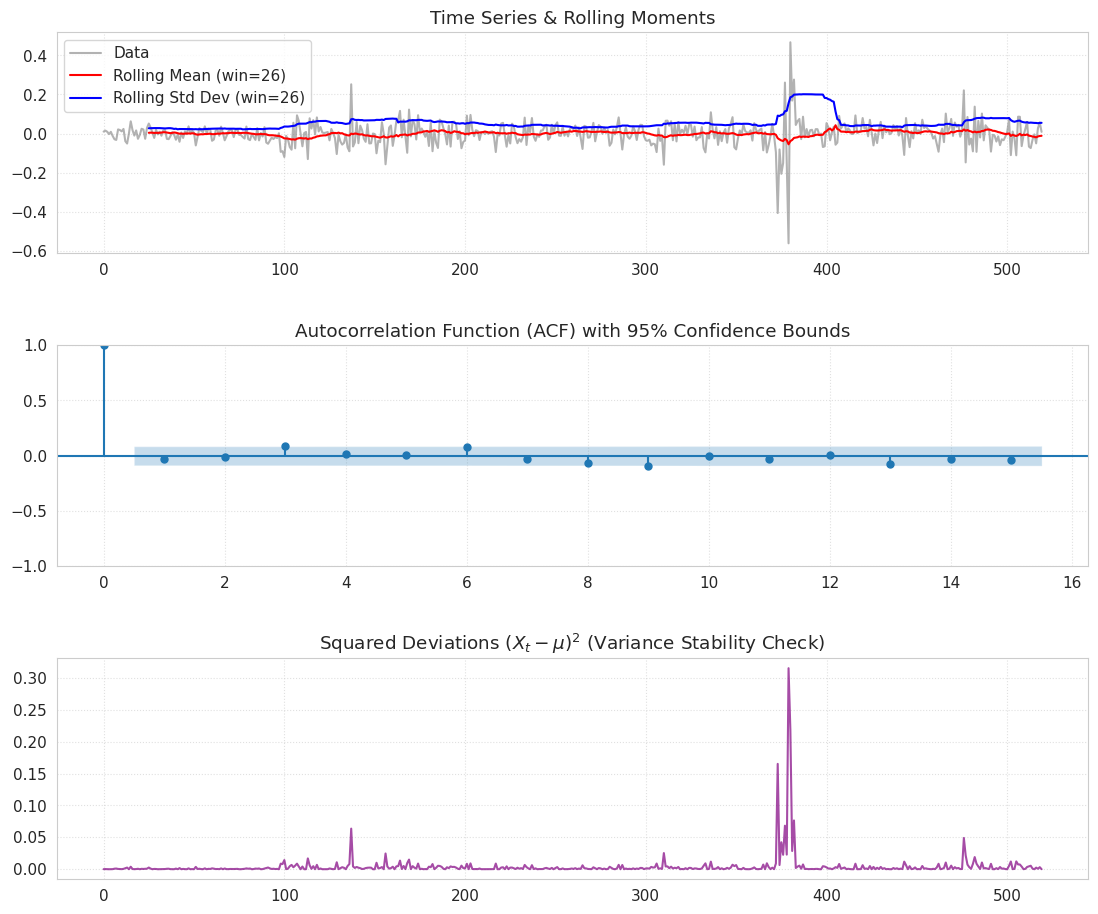


 TESTIRANJE BELE BUKE ZA: Δlog_BRENT
        WEAK WHITE NOISE DIAGNOSTIC REPORT          

1. AUTOCORRELATION TESTS (Linear Independence)
   • Ljung-Box Test (Lag 15): p-value = 0.0909
   --> RESULT: PASS (No significant autocorrelation detected)

2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)
   • ADF Statistic: -12.1938
   • p-value: 0.0000
   --> RESULT: PASS (Series is stationary around a constant mean)

3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)
   • ARCH LM p-value: 0.0000
   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)

------------------------------------------------------------
FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).
------------------------------------------------------------


/tmp/ipykernel_3525/1664317080.py:37: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_result = het_arch(demeaned_series, maxlag=lags)


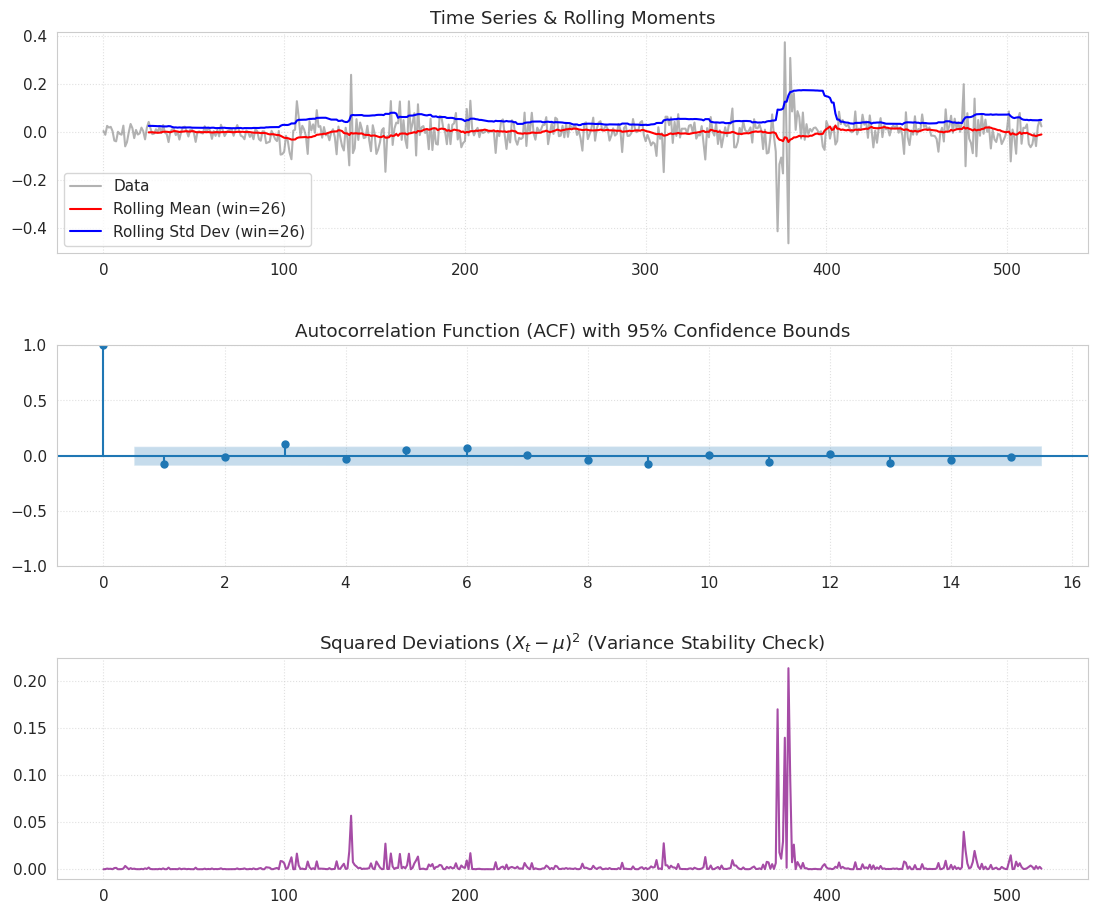


 TESTIRANJE BELE BUKE ZA: Δlog_NVDA
        WEAK WHITE NOISE DIAGNOSTIC REPORT          

1. AUTOCORRELATION TESTS (Linear Independence)
   • Ljung-Box Test (Lag 15): p-value = 0.8489
   --> RESULT: PASS (No significant autocorrelation detected)

2. STATIONARITY & CONSTANT MEAN TEST (ADF Test)
   • ADF Statistic: -17.6010
   • p-value: 0.0000
   --> RESULT: PASS (Series is stationary around a constant mean)

3. HOMOSCEDASTICITY / CONSTANT VARIANCE (Engle's ARCH Test)
   • ARCH LM p-value: 0.0000
   --> RESULT: FAIL (Conditional heteroscedasticity / Volatility clustering present)

------------------------------------------------------------
FINAL VERDICT: WEAK WHITE NOISE for linear terms, BUT shows non-linear variance dependence (ARCH effects).
------------------------------------------------------------


/tmp/ipykernel_3525/1664317080.py:37: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_result = het_arch(demeaned_series, maxlag=lags)


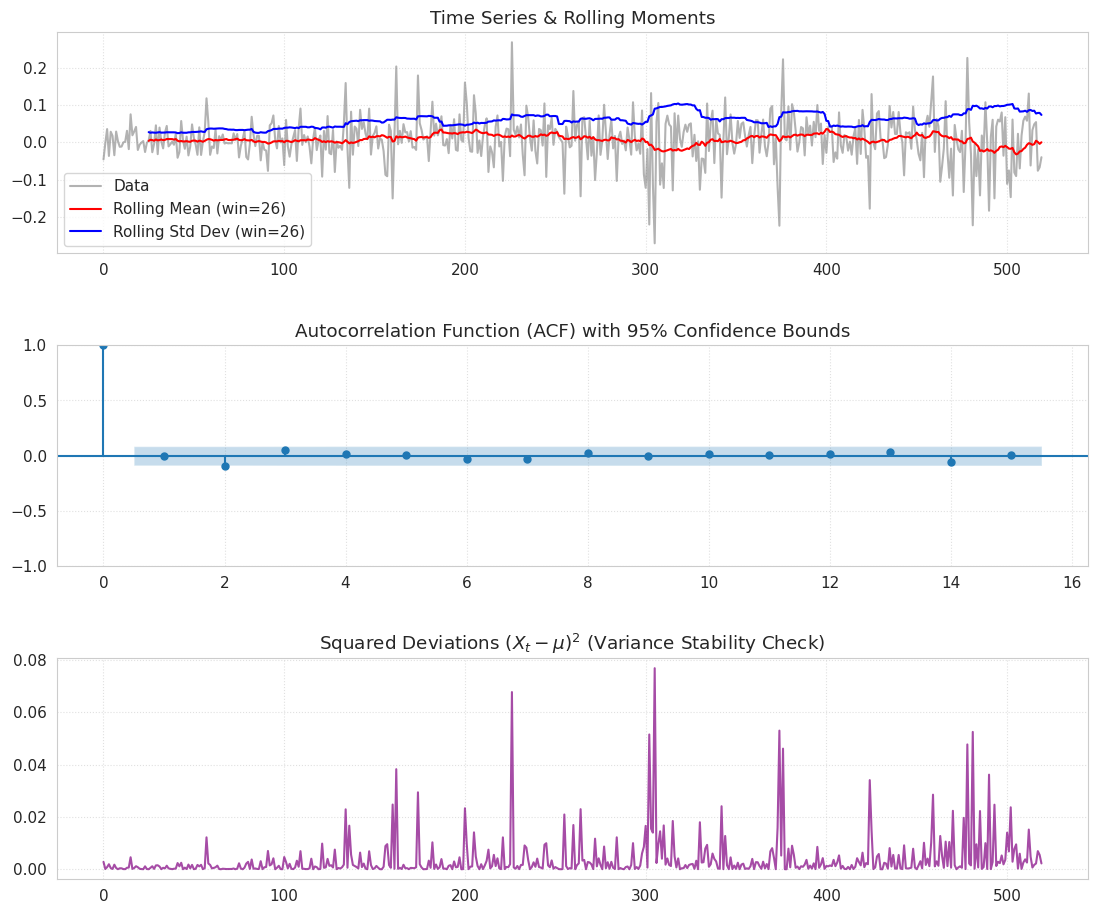

In [ ]:
for col in log_razlike.columns:
    print(f"\n=======================================================")
    print(f" TESTIRANJE BELE BUKE ZA: {col}")
    print(f"=======================================================")

    evaluate_white_noise(log_razlike[col], lags=15)


POČETAK AR(1) ANALIZE I TESTA JEDINIČNOG KORENA

--- Analiza za instrument: WTI ---
Ocenjeni parametri:
b = 0.982500
a = 0.071938
Osobine reziduala:
Srednja vrednost e_t: -0.0000000000
Srednja varijansa e_t: 0.004116
ZAKLJUČAK TESTA: Proces je kovarijansno stacioniran.

--- Analiza za instrument: BRENT ---
Ocenjeni parametri:
b = 0.984038
a = 0.066619
Osobine reziduala:
Srednja vrednost e_t: -0.0000000000
Srednja varijansa e_t: 0.003439
ZAKLJUČAK TESTA: Proces je kovarijansno stacioniran.

--- Analiza za instrument: NVDA ---
Ocenjeni parametri:
b = 0.998083
a = 0.009346
Osobine reziduala:
Srednja vrednost e_t: -0.0000000000
Srednja varijansa e_t: 0.003847
ZAKLJUČAK TESTA: Proces je random wlak.

--- Analiza za instrument: WTI ---
Ocenjeni parametri:
b = -0.032573
a = -0.000317
Osobine reziduala:
Srednja vrednost e_t: 0.0000000000
Srednja varijansa e_t: 0.004157
ZAKLJUČAK TESTA: Proces je kovarijansno stacioniran.

--- Analiza za instrument: BRENT ---
Ocenjeni parametri:
b = -0.076816


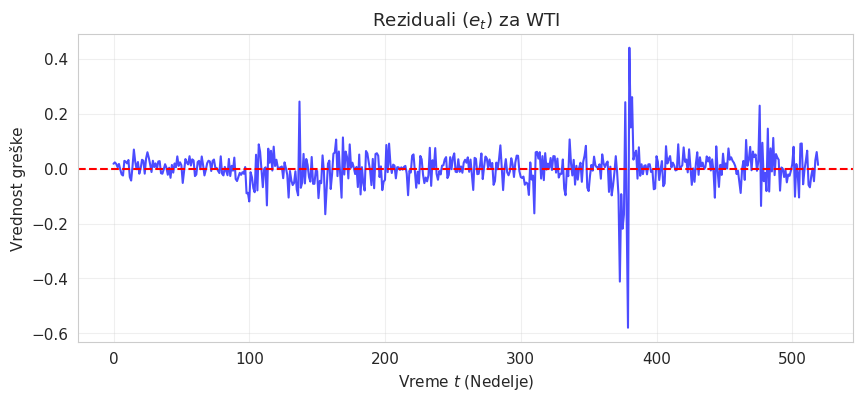

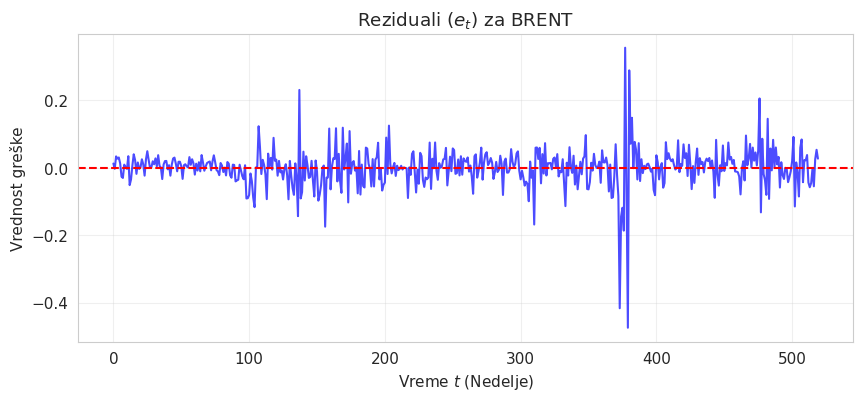

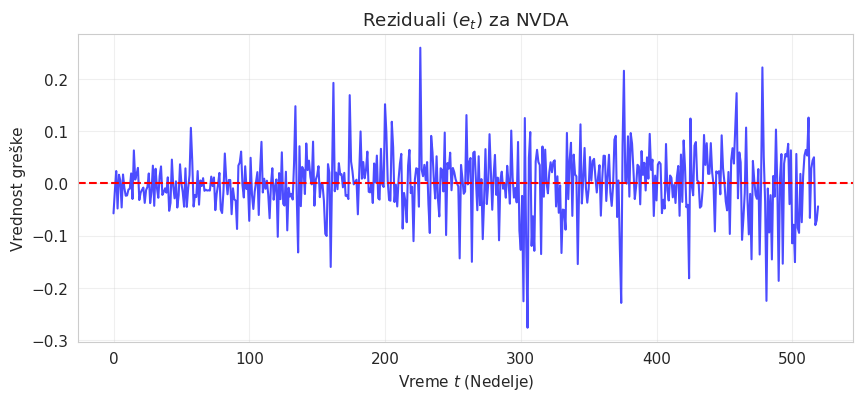

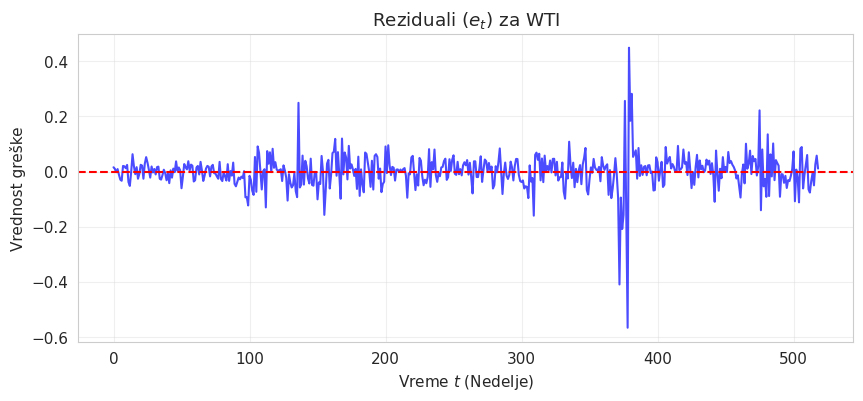

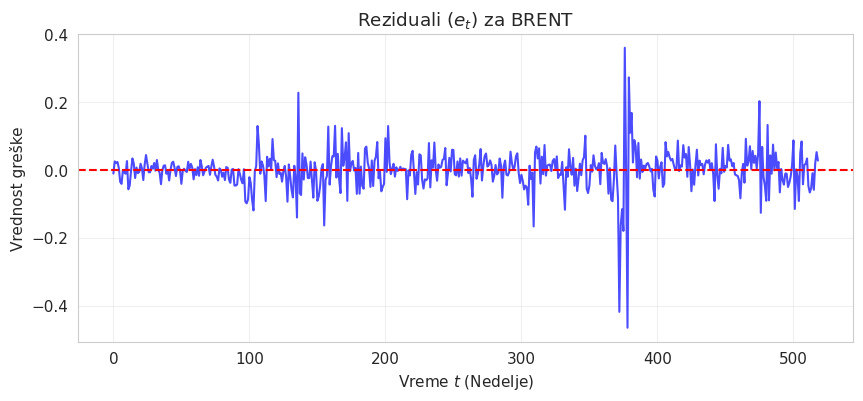

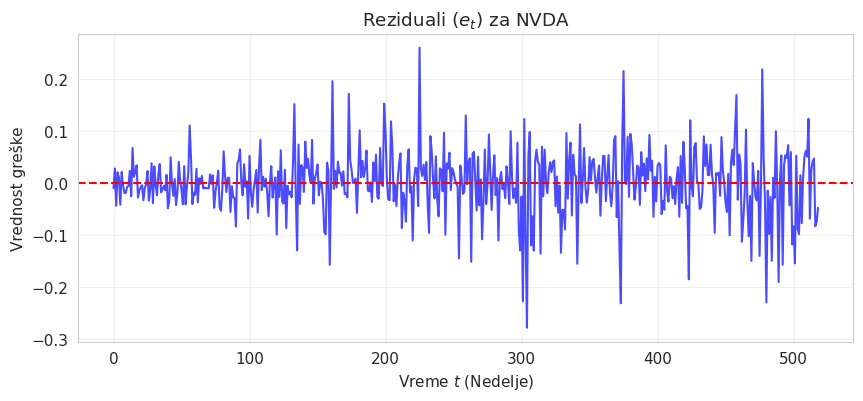

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# start_date = "2013-01-01"
# end_date   = "2023-01-01"

# tikeri = {
#     "WTI":   "CL=F",
#     "BRENT": "BZ=F",
#     "NVDA":  "NVDA"
# }

# podaci = {}
# for naziv, tiker in tikeri.items():
#     df = yf.download(tiker, start=start_date, end=end_date, interval="1wk",
#                      progress=False, auto_adjust=False)
#     podaci[naziv] = df['Close'].copy()

# cene = pd.concat(podaci, axis=1)
# cene.columns = tikeri.keys()
# cene = cene.dropna()

# print("Prvih 5 redova sirovih cena:")
# print(cene.head())
# print("\nDimenzije:", cene.shape)
# cene = cene[cene > 0].dropna()

# log_cene = np.log(cene)
# log_cene.columns = [f"log_{c}" for c in log_cene.columns]

# log_razlike = log_cene.diff().dropna()
# log_razlike.columns = [f"Δ{col}" for col in log_razlike.columns]

# print("\nPrvih 5 redova log-cena:")
# print(log_cene.head(3))
# print("\nPrvih 5 redova log-razlika (prinosa):")
# print(log_razlike.head(3))

# (Tvoji prethodni grafikoni za cene i razlike su ovde izostavljeni radi uštede prostora,
# ali možeš ih slobodno ostaviti u svom fajlu)

# ==========================================
# IMPLEMENTACIJA AR(1) MODELA I TESTA JEDINIČNOG KORENA
# ==========================================

print("\n" + "="*50)
print("POČETAK AR(1) ANALIZE I TESTA JEDINIČNOG KORENA")
print("="*50 + "\n")

# Funkcija koja izvršava ceo proces na jednom nizu (jednoj koloni iz Pandas DataFrame-a)
def analiziraj_ar1(serija_cena, naziv_instrumenta):
    print(f"--- Analiza za instrument: {naziv_instrumenta} ---")

    # Prebacujemo Pandas Series u NumPy array za brži rad i lakše indeksiranje
    niz_cena = serija_cena.values

    # Korak 1: Priprema podataka (Kreiranje pomaka - Lagging)
    X_t = niz_cena[:-1]
    X_t_plus_1 = niz_cena[1:]

    # Korak 2: Ocenjivanje parametara 'a' i 'b' primenom MNK
    mean_X_t = np.mean(X_t)
    mean_X_t_plus_1 = np.mean(X_t_plus_1)

    brojilac = np.sum((X_t - mean_X_t) * (X_t_plus_1 - mean_X_t_plus_1))
    imenilac = np.sum((X_t - mean_X_t)**2)
    b = brojilac / imenilac
    a = mean_X_t_plus_1 - b * mean_X_t

    print(f"Ocenjeni parametri:")
    print(f"b = {b:.6f}")
    print(f"a = {a:.6f}")

    # Korak 3: Izdvajanje i provera reziduala (e_t)
    e_t = X_t_plus_1 - (a + b * X_t)
    mean_e_t = np.mean(e_t)
    var_e_t = np.var(e_t)

    print(f"Osobine reziduala:")
    print(f"Srednja vrednost e_t: {mean_e_t:.10f}")
    print(f"Srednja varijansa e_t: {var_e_t:.6f}")

    # Vizuelna provera reziduala
    # AKO INSTALIRAŠ statsmodels, PROMENI SLEDEĆI BLOK DA CRTA I ACF
    plt.figure(figsize=(10, 4))
    plt.plot(e_t, color='blue', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Reziduali ($e_t$) za {naziv_instrumenta}')
    plt.xlabel('Vreme $t$ (Nedelje)')
    plt.ylabel('Vrednost greške')
    plt.grid(True, alpha=0.3)
    #plt.show()

    # Korak 4: Interpretacija (Test jediničnog korena)
    tolerancija = 0.01

    if abs(b) > 1 + tolerancija:
         zakljucak = "Proces divergira."
    elif abs(b - 1) <= tolerancija:
         zakljucak = "Proces je random wlak."
    elif abs(b) < 1:
         zakljucak = "Proces je kovarijansno stacioniran."
    else:
         zakljucak = "Granični slučaj koji zahteva dodatna ispitivanja."

    print(f"ZAKLJUČAK TESTA: {zakljucak}\n")
    return e_t

# Pokrećemo analizu za svaku od tri log-cene iz tvog DataFrame-a
for kolona in log_cene.columns:
    # Izvlačimo naziv bez 'log_' prefiksa radi lepšeg ispisa
    naziv = kolona.replace("log_", "")
    analiziraj_ar1(log_cene[kolona], naziv)
# reziduali AR(1) nad LOG-RAZLIKAMA -> ulaz za deo 3
reziduali = {}
for kolona in log_razlike.columns:
    naziv = kolona.replace("Δlog_", "").replace("log_", "").replace("Δ", "")
    reziduali[naziv] = analiziraj_ar1(log_razlike[kolona], naziv)


DEO 3: TEST ELIPSE (reziduali AR(1) nad log-razlikama)

===== TEST ELIPSE: WTI =====
  k=1 (parni/neparni)     λ1/λ2= 1.56  korel=-0.1860  centar=(-0.0022, +0.0022)  ->  blago izduzeno
  k=2                     λ1/λ2= 1.01  korel=-0.0055  centar=(-0.0001, -0.0000)  ->  KRUG
  k=3                     λ1/λ2= 1.21  korel=+0.0930  centar=(-0.0002, -0.0000)  ->  KRUG


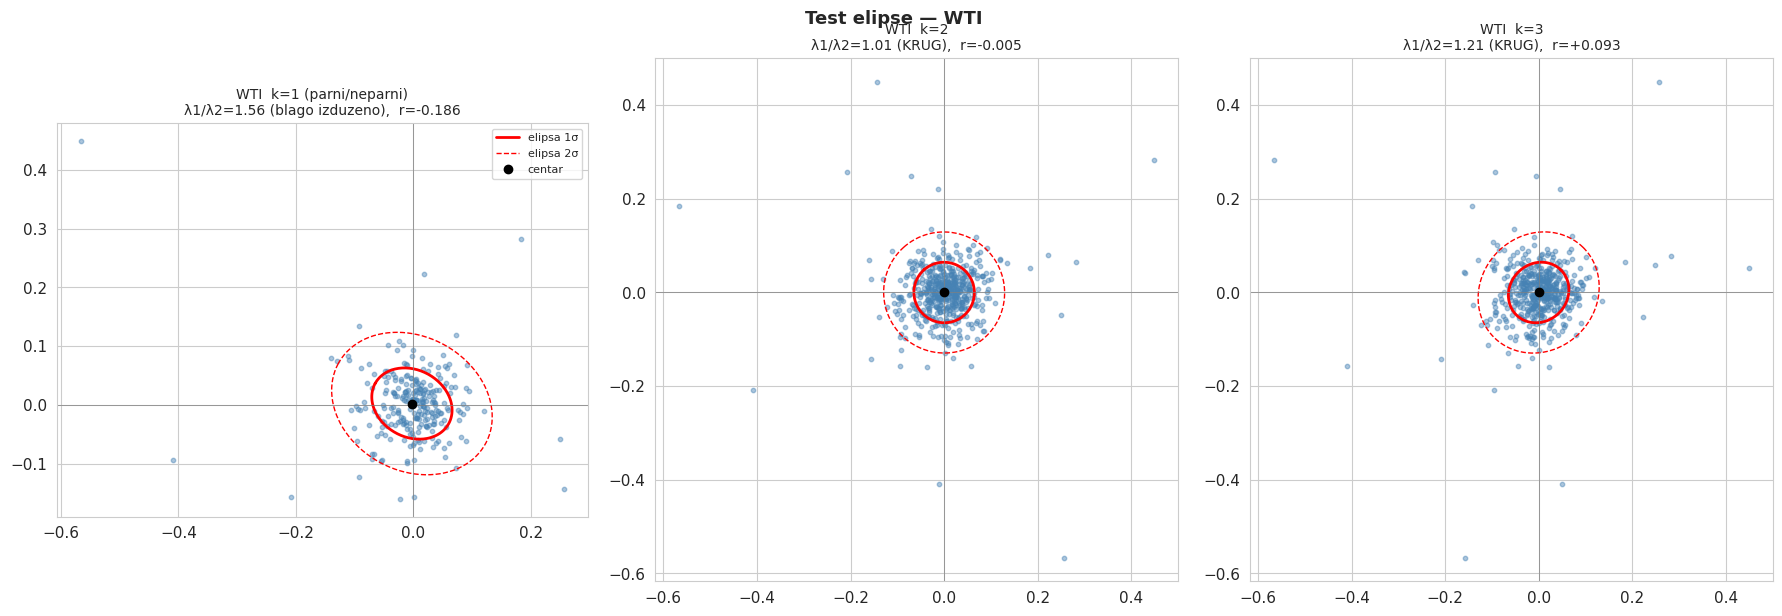

  ZAKLJUCAK: k=1 odnos=1.56 (blago izduzeno); k>=2 odnosi=[np.float64(1.01), np.float64(1.21)] (KRUG, KRUG).
             Elipsa na k=1 -> krug na k>=2: kratkorocna zavisnost nestaje, reziduali se brzo obele.

===== TEST ELIPSE: BRENT =====
  k=1 (parni/neparni)     λ1/λ2= 1.50  korel=-0.0395  centar=(-0.0011, +0.0010)  ->  blago izduzeno
  k=2                     λ1/λ2= 1.02  korel=-0.0117  centar=(-0.0002, -0.0000)  ->  KRUG
  k=3                     λ1/λ2= 1.23  korel=+0.1046  centar=(-0.0002, -0.0001)  ->  KRUG


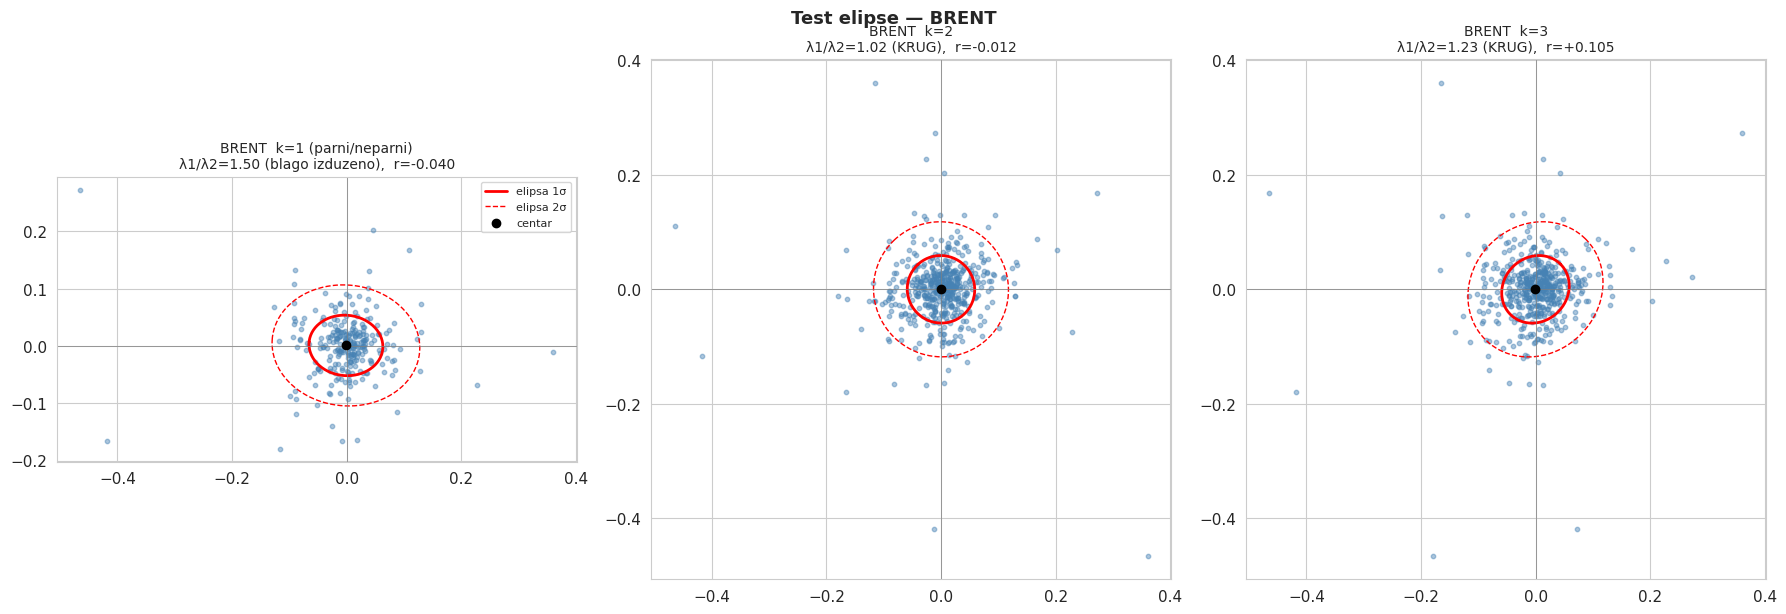

  ZAKLJUCAK: k=1 odnos=1.50 (blago izduzeno); k>=2 odnosi=[np.float64(1.02), np.float64(1.23)] (KRUG, KRUG).
             Elipsa na k=1 -> krug na k>=2: kratkorocna zavisnost nestaje, reziduali se brzo obele.

===== TEST ELIPSE: NVDA =====
  k=1 (parni/neparni)     λ1/λ2= 1.42  korel=+0.0163  centar=(-0.0006, +0.0008)  ->  blago izduzeno
  k=2                     λ1/λ2= 1.20  korel=-0.0898  centar=(+0.0002, -0.0000)  ->  KRUG
  k=3                     λ1/λ2= 1.11  korel=+0.0499  centar=(+0.0004, +0.0001)  ->  KRUG


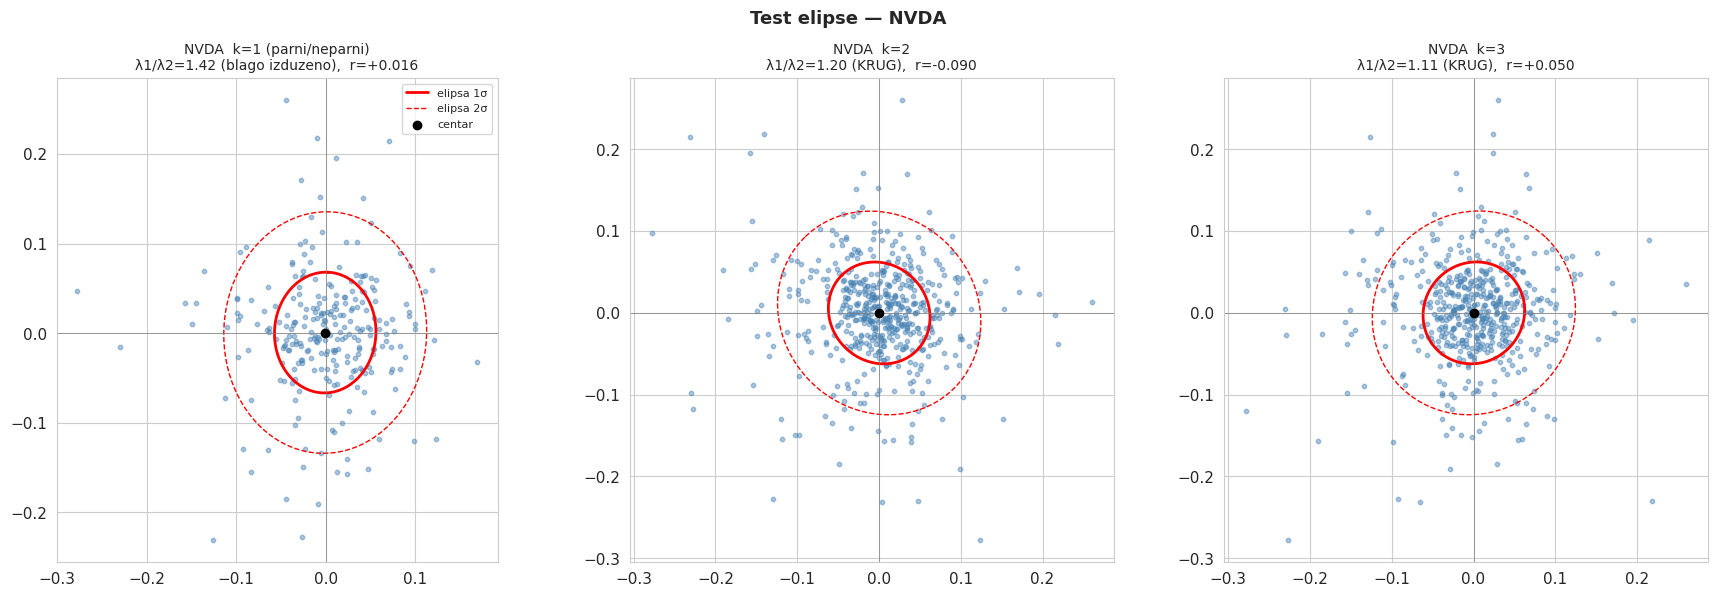

  ZAKLJUCAK: k=1 odnos=1.42 (blago izduzeno); k>=2 odnosi=[np.float64(1.2), np.float64(1.11)] (KRUG, KRUG).
             Elipsa na k=1 -> krug na k>=2: kratkorocna zavisnost nestaje, reziduali se brzo obele.



In [ ]:
# =============================================================================
# DEO 3 — Test elipse na rezidualima AR(1) modela (nad log-razlikama)
#
# Mentor: prvo k=1 kao PARNI/NEPARNI reziduali (ocekivano: elipsa),
#         zatim k=2 i k=3 kao (e_t, e_t+k)  (ocekivano: krug).
# Zakljucak: ako oblik prelazi iz elipse (k=1) u krug (k>=2), znaci da
# kratkorocna zavisnost postoji samo na malom lagu, a reziduali se brzo
# "obele" -> AR(1) je razumno uhvatio strukturu log-razlika.
#
# PRETPOSTAVKA: postoji dict 'reziduali' = {naziv: e_t_niz},
# dobijen pozivom analiziraj_ar1 nad log_razlike (uz 'return e_t').
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt


def _elipsa_parametri(x, y):
    """Iz dva niza vrati centar, kovar. matricu, sopstv. vrednosti/vektore, ugao, korelaciju."""
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    podaci = np.vstack([x, y])                 # 2 x n
    mu = podaci.mean(axis=1)                    # centar (ocena ocekivanja)
    C = np.cov(podaci)                          # 2x2 kovarijansna matrica
    lam, Q = np.linalg.eigh(C)                  # sopstvene vrednosti/vektori (C simetricna)
    idx = np.argsort(lam)[::-1]                 # sortiraj opadajuce: lam1 >= lam2
    lam, Q = lam[idx], Q[:, idx]
    theta = np.arctan2(Q[1, 0], Q[0, 0])        # ugao glavne ose
    korel = C[0, 1] / np.sqrt(C[0, 0] * C[1, 1])
    return x, y, mu, C, lam, Q, theta, korel, n


def _nacrtaj_elipsu(ax, x, y, mu, lam, Q, naslov):
    """Jedinicni krug -> skaliraj sqrt(lam) -> rotiraj Q -> pomeri u mu."""
    t = np.linspace(0, 2 * np.pi, 200)
    krug = np.vstack([np.cos(t), np.sin(t)])
    e1 = Q @ np.diag(np.sqrt(lam))     @ krug + mu[:, None]   # 1 sigma
    e2 = Q @ np.diag(2*np.sqrt(lam))   @ krug + mu[:, None]   # 2 sigma (~95%)
    ax.scatter(x, y, s=10, alpha=0.45, color="steelblue")
    ax.plot(e1[0], e1[1], "r-",  lw=2, label="elipsa 1σ")
    ax.plot(e2[0], e2[1], "r--", lw=1, label="elipsa 2σ")
    ax.scatter(*mu, color="black", zorder=5, label="centar")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_aspect("equal")
    ax.set_title(naslov, fontsize=10)


def _oblik(odnos):
    """Kvalitativna ocena oblika iz odnosa sopstvenih vrednosti."""
    if odnos < 1.3:
        return "KRUG"
    elif odnos < 2.0:
        return "blago izduzeno"
    else:
        return "ELIPSA"


def test_elipse(e_t, naziv, k_lista=(1, 2, 3)):
    """
    Za k=1 koristi PARNI/NEPARNI split (kako trazi zadatak),
    za k>=2 koristi klasicne parove (e_t, e_t+k).
    Crta sve k jedan pored drugog i vraca merne velicine.
    """
    e_t = np.asarray(e_t)
    fig, axes = plt.subplots(1, len(k_lista), figsize=(6 * len(k_lista), 6))
    if len(k_lista) == 1:
        axes = [axes]

    print(f"===== TEST ELIPSE: {naziv} =====")
    rezultat = {}
    for ax, k in zip(axes, k_lista):
        if k == 1:
            x, y = e_t[0::2], e_t[1::2]        # parni / neparni indeksi
            opis = "k=1 (parni/neparni)"
        else:
            x, y = e_t[:-k], e_t[k:]           # (e_t, e_t+k)
            opis = f"k={k}"

        x, y, mu, C, lam, Q, theta, korel, n = _elipsa_parametri(x, y)
        odnos = lam[0] / lam[1]
        oblik = _oblik(odnos)

        _nacrtaj_elipsu(ax, x, y, mu, lam, Q,
                        f"{naziv}  {opis}\nλ1/λ2={odnos:.2f} ({oblik}),  r={korel:+.3f}")

        print(f"  {opis:22s}  λ1/λ2={odnos:5.2f}  korel={korel:+.4f}  "
              f"centar=({mu[0]:+.4f}, {mu[1]:+.4f})  ->  {oblik}")
        rezultat[k] = dict(odnos=odnos, korel=korel, mu=mu, lam=lam, theta=theta)

    axes[0].legend(fontsize=8)
    fig.suptitle(f"Test elipse — {naziv}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # --- automatski zakljucak ---
    o1 = rezultat[1]["odnos"]
    o_visi = [rezultat[k]["odnos"] for k in k_lista if k >= 2]
    print(f"  ZAKLJUCAK: k=1 odnos={o1:.2f} ({_oblik(o1)}); "
          f"k>=2 odnosi={[round(v,2) for v in o_visi]} "
          f"({', '.join(_oblik(v) for v in o_visi)}).")
    if o1 >= 1.3 and all(v < 1.3 for v in o_visi):
        print("             Elipsa na k=1 -> krug na k>=2: kratkorocna zavisnost "
              "nestaje, reziduali se brzo obele.\n")
    elif all(v < 1.3 for v in [o1] + o_visi):
        print("             Vec na k=1 blizu kruga: reziduali prakticno nekorelisani "
              "na svim lagovima.\n")
    else:
        print("             Elipsa ostaje izduzena i za vece k: ima zaostale "
              "strukture koju AR(1) nije uhvatio.\n")
    return rezultat


# ---------------------------------------------------------------------------
print("\n" + "=" * 55)
print("DEO 3: TEST ELIPSE (reziduali AR(1) nad log-razlikama)")
print("=" * 55 + "\n")

rezultati_elipse = {}
for naziv, e_t in reziduali.items():
    rezultati_elipse[naziv] = test_elipse(e_t, naziv, k_lista=(1, 2, 3))

===== DEO 4A: provera Gaussovosti reziduala =====
broj odbiraka:      520
srednja vrednost:   -0.00029
std. devijacija:    0.06451
skewness:           -0.723   (normalna = 0)
excess kurtosis:    19.608   (normalna = 0; >0 znaci fat tails)
Jarque-Bera:        stat=8375.2,  p-value=0.00e+00
zakljucak:          NIJE normalna (fat tails)


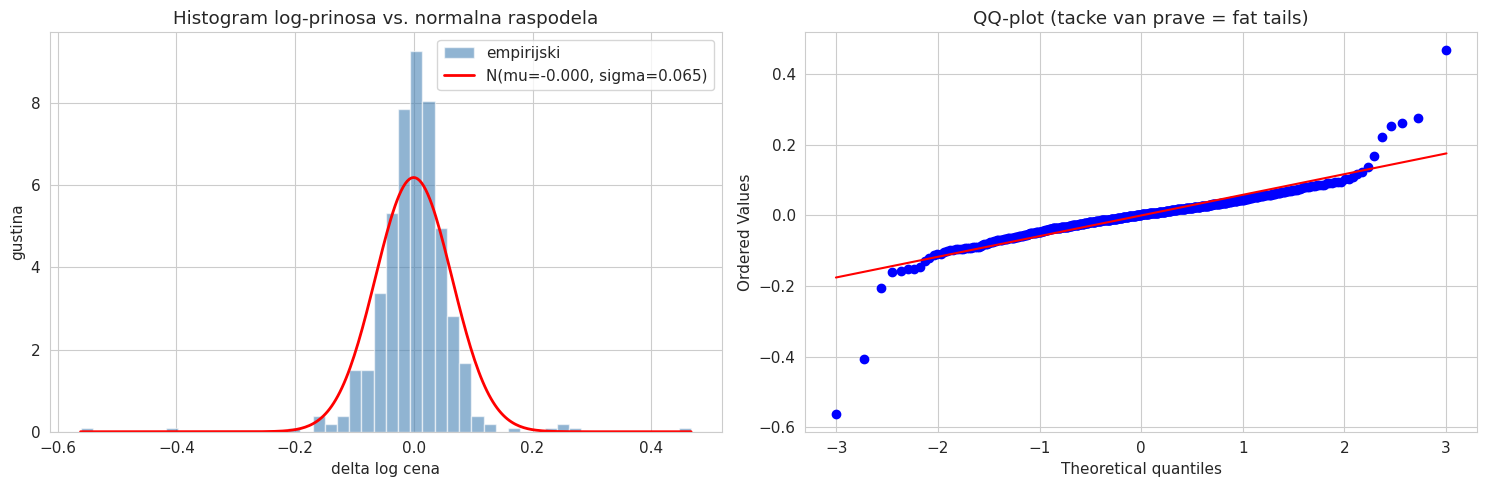


===== DEO 4B: Monte Carlo random walk =====
pocetna cena X0:    80.26
horizont:           52 nedelja,  broj putanja: 1000
ned. 52 -> prosek:  87.76
ned. 52 -> 90% int: [36.17, 171.26]
sirina opsega ned.1:  15.90
sirina opsega ned.52: 135.09   (siri se ~ sqrt(t))


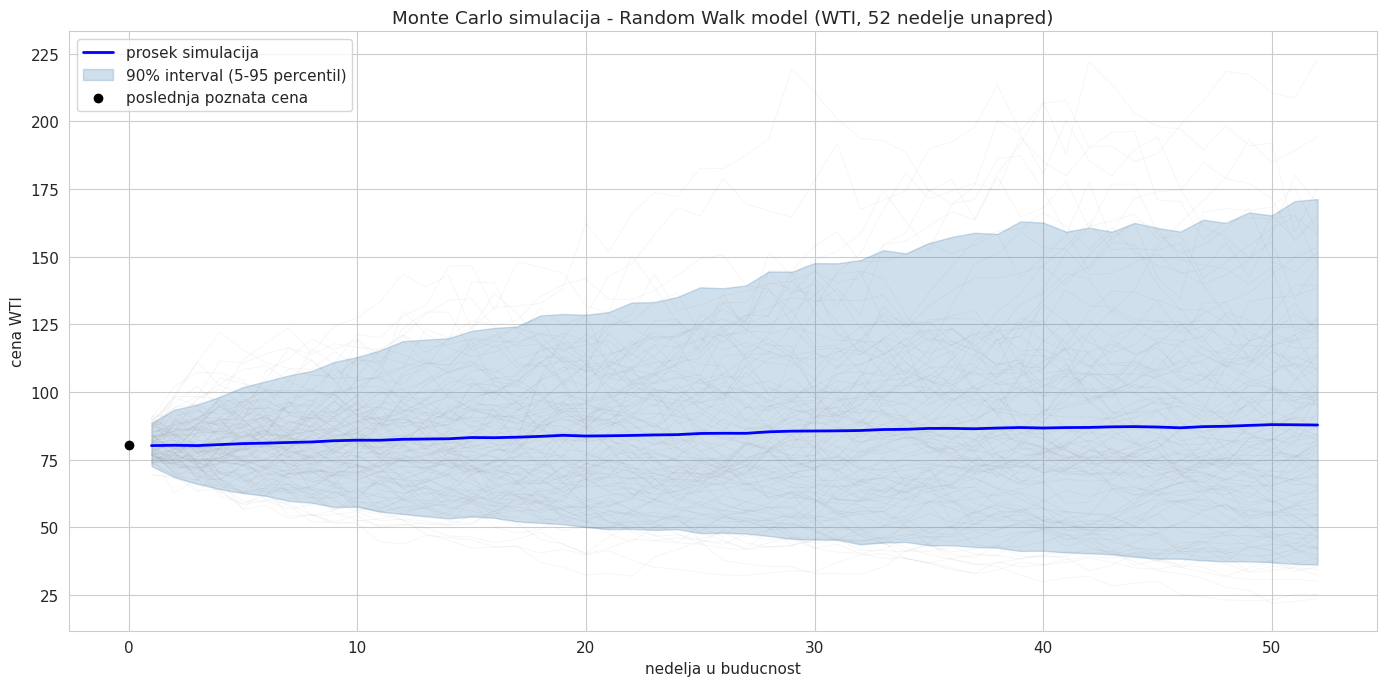

In [ ]:
"""
=============================================================================
DEO 4 — Random Walk model + Monte Carlo simulacija (WTI nafta)
Samostalni .py fajl (sam preuzima podatke preko yfinance).
=============================================================================
Model:  X_t = X_{t-1} + e_t,  e_t ~ N(mu, sigma^2)
(A) provera da li su reziduali e_t Gaussovi -> ispada da NISU (fat tails)
(B) Monte Carlo simulacija buducnosti        -> lepeza se siri, lose prati stvarnost
=============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

# ---------------------------------------------------------------------------
# PREUZIMANJE PODATAKA
# ---------------------------------------------------------------------------
cena = yf.download("CL=F", start="2013-01-01", end="2023-01-01",
                   interval="1wk", progress=False, auto_adjust=False)["Close"]

# 'Close' sa jednim tikerom ume da bude DataFrame sa kolonom 'CL=F' -> svedi na Series
if isinstance(cena, pd.DataFrame):
    cena = cena.iloc[:, 0]

cena = cena.dropna()
cena = cena[cena > 0]

log_WTI = np.log(cena)
log_WTI.name = "log_WTI"

log_ret_WTI = log_WTI.diff().dropna()
log_ret_WTI.name = "dlog_WTI"


# ===========================================================================
# DEO 4A — Da li su reziduali e_t = X_t - X_{t-1} Gaussov beli sum?
#   - histogram vs. teorijska normalna kriva
#   - QQ-plot (ako je normalno, tacke leze na pravoj)
#   - skewness i excess kurtosis (normalna: 0 i 0; fat tails -> kurtosis >> 0)
#   - Jarque-Bera test: p < 0.05 => odbacujemo normalnost
# ===========================================================================
e = log_ret_WTI.dropna()
mu, sigma = e.mean(), e.std()

skew = stats.skew(e)
exc_kurt = stats.kurtosis(e, fisher=True)      # Fisher: normalna -> 0
jb_stat, jb_p = stats.jarque_bera(e)

print("===== DEO 4A: provera Gaussovosti reziduala =====")
print(f"broj odbiraka:      {len(e)}")
print(f"srednja vrednost:   {mu:.5f}")
print(f"std. devijacija:    {sigma:.5f}")
print(f"skewness:           {skew:.3f}   (normalna = 0)")
print(f"excess kurtosis:    {exc_kurt:.3f}   (normalna = 0; >0 znaci fat tails)")
print(f"Jarque-Bera:        stat={jb_stat:.1f},  p-value={jb_p:.2e}")
print("zakljucak:         ", "NIJE normalna (fat tails)" if jb_p < 0.05
      else "ne mozemo odbaciti normalnost")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(e, bins=50, density=True, alpha=0.6, color="steelblue",
         edgecolor="white", label="empirijski")
x = np.linspace(e.min(), e.max(), 300)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2,
         label=f"N(mu={mu:.3f}, sigma={sigma:.3f})")
ax1.set_title("Histogram log-prinosa vs. normalna raspodela")
ax1.set_xlabel("delta log cena"); ax1.set_ylabel("gustina"); ax1.legend()

stats.probplot(e, dist="norm", plot=ax2)
ax2.set_title("QQ-plot (tacke van prave = fat tails)")

plt.tight_layout()
plt.show()


# ===========================================================================
# DEO 4B — Monte Carlo simulacija random walk modela
#   X_t = X_{t-1} + e_t,  e_t ~ N(mu, sigma^2)
#   Simuliramo M putanja, svaku H nedelja unapred, od poslednje log cene X0.
# ===========================================================================
H = 52        # horizont: 52 nedelje unapred
M = 1000      # broj Monte Carlo putanja
X0 = log_WTI.iloc[-1]

rng = np.random.default_rng(0)                   # fiksan seed radi ponovljivosti
sokovi = rng.normal(mu, sigma, size=(H, M))      # H x M: stubac = putanja
putanje_log = X0 + np.cumsum(sokovi, axis=0)     # random walk = kumulativna suma sokova
putanje_cena = np.exp(putanje_log)               # nazad iz log u cene

sredina = putanje_cena.mean(axis=1)
p05 = np.percentile(putanje_cena, 5, axis=1)
p95 = np.percentile(putanje_cena, 95, axis=1)

nedelje = np.arange(1, H + 1)
cena0 = float(np.exp(X0))

print("\n===== DEO 4B: Monte Carlo random walk =====")
print(f"pocetna cena X0:    {cena0:.2f}")
print(f"horizont:           {H} nedelja,  broj putanja: {M}")
print(f"ned. 52 -> prosek:  {sredina[-1]:.2f}")
print(f"ned. 52 -> 90% int: [{p05[-1]:.2f}, {p95[-1]:.2f}]")
print(f"sirina opsega ned.1:  {p95[0]-p05[0]:.2f}")
print(f"sirina opsega ned.52: {p95[-1]-p05[-1]:.2f}   (siri se ~ sqrt(t))")

plt.figure(figsize=(14, 7))
for j in range(min(100, M)):
    plt.plot(nedelje, putanje_cena[:, j], color="gray", alpha=0.08, linewidth=0.6)
plt.plot(nedelje, sredina, "b-", linewidth=2, label="prosek simulacija")
plt.fill_between(nedelje, p05, p95, color="steelblue", alpha=0.25,
                 label="90% interval (5-95 percentil)")
plt.scatter([0], [cena0], color="black", zorder=5, label="poslednja poznata cena")
plt.title("Monte Carlo simulacija - Random Walk model (WTI, 52 nedelje unapred)")
plt.xlabel("nedelja u buducnost"); plt.ylabel("cena WTI")
plt.legend(); plt.tight_layout()
plt.show()


# ===========================================================================
# (opciono) POREDJENJE SA STVARNOM REALIZACIJOM
# Poslednjih 10 nedeljnih cena WTI od 5. marta 2025.
# ===========================================================================
# stvarne = yf.download("CL=F", start="2025-03-05", interval="1wk",
#                       progress=False, auto_adjust=False)["Close"]
# if isinstance(stvarne, pd.DataFrame):
#     stvarne = stvarne.iloc[:, 0]
# stvarne = stvarne.dropna().iloc[:10]
# plt.figure(figsize=(12, 6))
# plt.plot(range(1, len(stvarne) + 1), stvarne.values, "r-o", label="stvarna cena (2025)")
# plt.plot(nedelje[:10], sredina[:10], "b--", label="prosek simulacija")
# plt.fill_between(nedelje[:10], p05[:10], p95[:10], alpha=0.2)
# plt.legend(); plt.title("Simulacija vs. stvarnost - prvih 10 nedelja")
# plt.tight_layout(); plt.show()

#print("\nGOTOVO. Deo 4 kompletan.")


In [ ]:
# ==========================================
# ANALIZA VREMENA POLURASPADA (HALF-LIFE)
# ==========================================

print("="*60)
print("POČETAK ANALIZE VREMENA POLURASPADA (b^k = 0.5)")
print("="*60 + "\n")

import numpy as np

def izracunaj_poluraspad(serija_cena, naziv_instrumenta, tip_serije):
    # Priprema podataka
    X_t = serija_cena.values[:-1]
    X_t_plus_1 = serija_cena.values[1:]

    # MNK ocena parametra b
    mean_X_t = np.mean(X_t)
    mean_X_t_plus_1 = np.mean(X_t_plus_1)

    brojilac = np.sum((X_t - mean_X_t) * (X_t_plus_1 - mean_X_t_plus_1))
    imenilac = np.sum((X_t - mean_X_t)**2)
    b = brojilac / imenilac

    # Računanje vremena poluraspada (k) uz obradu graničnih slučajeva
    if b >= 1:
        k = float('inf')
        opis = "Beskonačno (proces ne konvergira, b >= 1)"
    elif b <= 0:
        k = 0
        opis = "Trenutno (proces oscilira, b <= 0)"
    else:
        k = np.log(0.5) / np.log(b)
        opis = f"{k:.2f} nedelja"

    print(f"[{tip_serije}] Instrument: {naziv_instrumenta}")
    print(f"  Parametar b = {b:.6f}")
    print(f"  Vreme poluraspada (k) = {opis}\n")

# 1. Analiza za logaritamske cene
print("--- LOGARITAMSKE CENE (Ponašaju se kao Random Walk) ---")
for kolona in log_cene.columns:
    naziv = kolona.replace("log_", "")
    izracunaj_poluraspad(log_cene[kolona], naziv, "Log-Cene")

print("-" * 60 + "\n")

# 2. Analiza za razlike logaritamskih cena (prinosi)
print("--- RAZLIKE LOGARITAMSKIH CENA (Nedeljni prinosi) ---")
for kolona in log_razlike.columns:
    naziv = kolona.replace("Δlog_", "").replace("log_", "")
    izracunaj_poluraspad(log_razlike[kolona], naziv, "Prinosi")

POČETAK ANALIZE VREMENA POLURASPADA (b^k = 0.5)

--- LOGARITAMSKE CENE (Ponašaju se kao Random Walk) ---
[Log-Cene] Instrument: WTI
  Parametar b = 0.982500
  Vreme poluraspada (k) = 39.26 nedelja

[Log-Cene] Instrument: BRENT
  Parametar b = 0.984038
  Vreme poluraspada (k) = 43.08 nedelja

[Log-Cene] Instrument: NVDA
  Parametar b = 0.998083
  Vreme poluraspada (k) = 361.15 nedelja

------------------------------------------------------------

--- RAZLIKE LOGARITAMSKIH CENA (Nedeljni prinosi) ---
[Prinosi] Instrument: WTI
  Parametar b = -0.032573
  Vreme poluraspada (k) = Trenutno (proces oscilira, b <= 0)

[Prinosi] Instrument: BRENT
  Parametar b = -0.076816
  Vreme poluraspada (k) = Trenutno (proces oscilira, b <= 0)

[Prinosi] Instrument: NVDA
  Parametar b = -0.005528
  Vreme poluraspada (k) = Trenutno (proces oscilira, b <= 0)



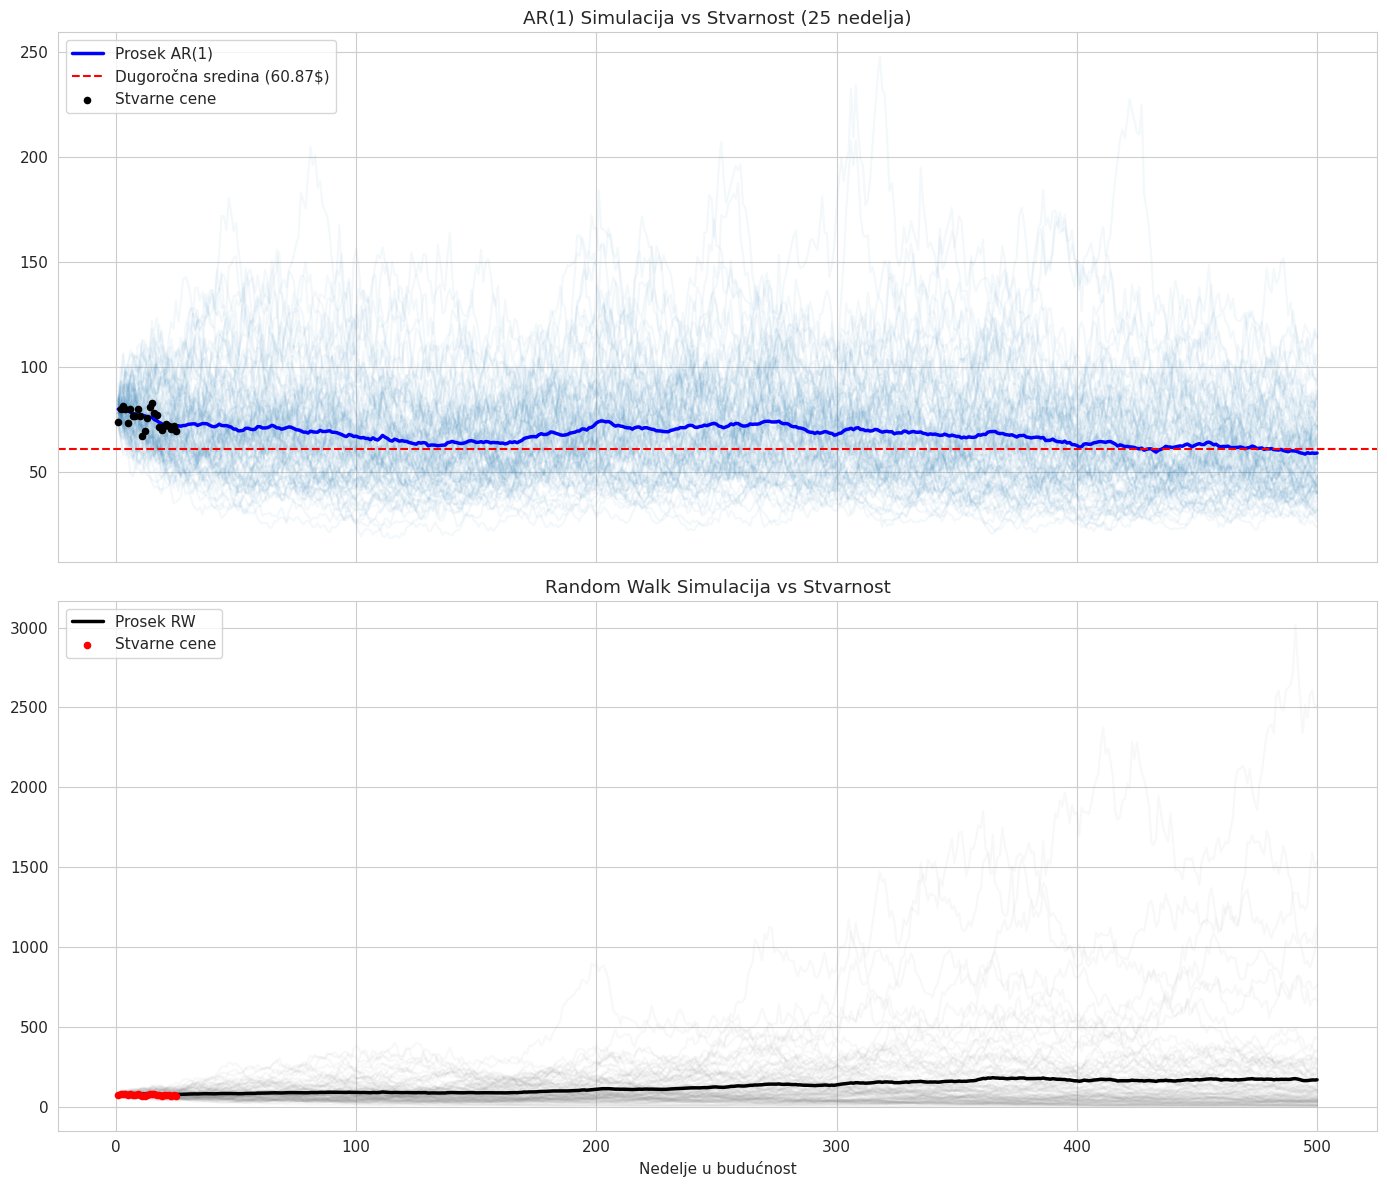


 POREĐENJE STVARNIH I SIMULIRANIH CENA (PRVIH 25 NEDELJA)
Nedelja  | Stvarna    | Prosek AR(1)    | Prosek RW      
----------------------------------------------------------------------
1        | 73.77      | 79.75           | 80.08          
2        | 79.86      | 79.54           | 80.18          
3        | 81.31      | 79.06           | 80.01          
4        | 79.68      | 79.38           | 80.65          
5        | 73.39      | 78.92           | 80.50          
6        | 79.72      | 78.37           | 80.25          
7        | 76.34      | 77.72           | 79.89          
8        | 76.32      | 77.56           | 80.02          
9        | 79.68      | 76.53           | 79.23          
10       | 76.68      | 76.88           | 79.87          
11       | 66.74      | 76.88           | 80.15          
12       | 69.26      | 76.56           | 80.11          
13       | 75.67      | 75.98           | 79.76          
14       | 80.70      | 75.83           | 79.89          


/tmp/ipykernel_1092/1458497521.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stvar = float(stvarni_podaci.values[i])


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# 1. Dinamičko preuzimanje parametara AR(1) za log_WTI
serija = log_cene['log_WTI']
X_t_vals = serija.values[:-1]
X_next_vals = serija.values[1:]

b_ar1 = np.cov(X_t_vals, X_next_vals)[0, 1] / np.var(X_t_vals)
a_ar1 = np.mean(X_next_vals) - b_ar1 * np.mean(X_t_vals)
var_e_ar1 = np.var(X_next_vals - (a_ar1 + b_ar1 * X_t_vals))
sigma_e_ar1 = np.sqrt(var_e_ar1)
mu_long_run = a_ar1 / (1 - b_ar1)

# 2. Dohvatanje podataka za validaciju (25 nedelja)
valid_df = yf.download("CL=F", start="2023-01-02", end="2023-07-15", interval="1wk", progress=False, auto_adjust=True)
stvarni_podaci = valid_df['Close'].dropna().iloc[:25]

# 3. Postavka simulacije
H = 500
M = 100
X0 = serija.iloc[-1]
rng = np.random.default_rng(42)

putanje_ar1 = np.zeros((H, M))
putanje_rw = np.zeros((H, M))
last_ar1 = np.full(M, X0)
last_rw = np.full(M, X0)

for t in range(H):
    sokovi = rng.normal(0, 1, M)
    next_ar1 = a_ar1 + b_ar1 * last_ar1 + sokovi * sigma_e_ar1
    putanje_ar1[t, :] = next_ar1
    last_ar1 = next_ar1

    next_rw = last_rw + mu + sokovi * sigma
    putanje_rw[t, :] = next_rw
    last_rw = next_rw

cene_ar1 = np.exp(putanje_ar1)
cene_rw = np.exp(putanje_rw)

# 4. Vizuelizacija
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
t_osa = np.arange(1, H + 1)

ax1.plot(t_osa, cene_ar1, color='tab:blue', alpha=0.05)
ax1.plot(t_osa, cene_ar1.mean(axis=1), color='blue', linewidth=2.5, label='Prosek AR(1)')
ax1.axhline(np.exp(mu_long_run), color='red', linestyle='--', label=f'Dugoročna sredina ({np.exp(mu_long_run):.2f}$)')
if len(stvarni_podaci) > 0:
    ax1.scatter(np.arange(1, len(stvarni_podaci)+1), stvarni_podaci.values, color='black', s=20, zorder=5, label='Stvarne cene')
ax1.set_title(f'AR(1) Simulacija vs Stvarnost (25 nedelja)')
ax1.legend()

ax2.plot(t_osa, cene_rw, color='tab:gray', alpha=0.05)
ax2.plot(t_osa, cene_rw.mean(axis=1), color='black', linewidth=2.5, label='Prosek RW')
if len(stvarni_podaci) > 0:
    ax2.scatter(np.arange(1, len(stvarni_podaci)+1), stvarni_podaci.values, color='red', s=20, zorder=5, label='Stvarne cene')
ax2.set_title('Random Walk Simulacija vs Stvarnost')
ax2.set_xlabel('Nedelje u budućnost')
ax2.legend()

plt.tight_layout()
plt.show()

# 5. Ispis poređenja vrednosti (popravljeno formatiranje)
print("\n" + "="*70)
print(f" POREĐENJE STVARNIH I SIMULIRANIH CENA (PRVIH {len(stvarni_podaci)} NEDELJA)")
print("="*70)
print(f"{'Nedelja':<8} | {'Stvarna':<10} | {'Prosek AR(1)':<15} | {'Prosek RW':<15}")
print("-"*70)

za_poredjenje = min(len(stvarni_podaci), H)
prosek_ar1_vals = cene_ar1.mean(axis=1)
prosek_rw_vals = cene_rw.mean(axis=1)

for i in range(za_poredjenje):
    stvar = float(stvarni_podaci.values[i])
    sim_ar1 = float(prosek_ar1_vals[i])
    sim_rw = float(prosek_rw_vals[i])
    print(f"{i+1:<8} | {stvar:<10.2f} | {sim_ar1:<15.2f} | {sim_rw:<15.2f}")

print("="*70)